# Análise Preditiva de Custos Médicos (Insurance Dataset - Kaggle)
Este notebook realiza uma análise completa do conjunto de dados `insurance.csv`, abordando tarefas de regressão e classificação para prever custos médicos e identificar pacientes de alto custo.

**Tarefas:**
- Regressão Linear para prever `charges` a partir de variáveis demográficas e comportamentais.
- Classificação Logística para identificar pacientes de alto custo (`high_cost`).
- Avaliação de métricas, interpretação dos coeficientes, comparação de limiares e boas práticas de pipeline.

**Fonte dos dados:** [Kaggle - Medical Cost Personal Datasets](https://www.kaggle.com/datasets/mirichoi0218/insurance)

In [1]:
# Importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, confusion_matrix, f1_score, roc_auc_score, roc_curve


In [2]:
# Carregamento dos dados
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


## Descrição inicial dos dados
Vamos explorar as variáveis e estatísticas básicas do dataset para entender sua estrutura.

In [3]:
# Informações gerais do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [4]:
# Estatísticas descritivas
df.describe(include='all')

,age,sex,bmi,children,smoker,region,charges
count,1338.000000,1338,1338.000000,1338.000000,1338,1338,1338.000000
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.207025,NaN,30.663397,1.094918,NaN,NaN,13270.422265
std,14.049960,NaN,6.098187,1.205493,NaN,NaN,12110.011237
min,18.000000,NaN,15.960000,0.000000,NaN,NaN,1121.873900
25%,27.000000,NaN,26.296250,0.000000,NaN,NaN,4740.287150
50%,39.000000,NaN,30.400000,1.000000,NaN,NaN,9382.033000
75%,51.000000,NaN,34.693750,2.000000,NaN,NaN,16639.912515


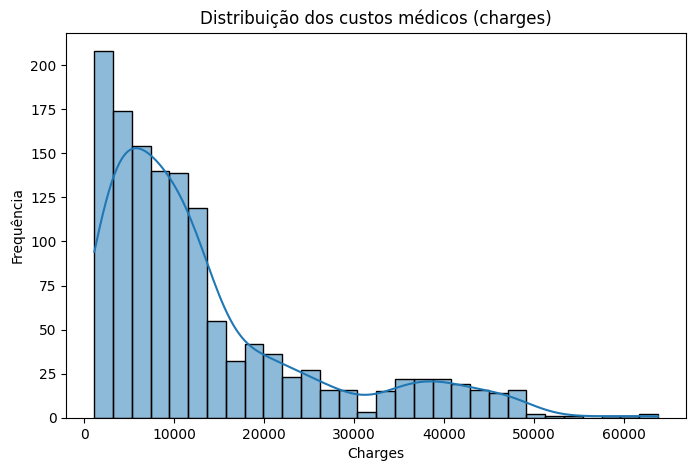

In [5]:
# Visualização da distribuição dos custos médicos (charges)
plt.figure(figsize=(8,5))
sns.histplot(df['charges'], bins=30, kde=True)
plt.title('Distribuição dos custos médicos (charges)')
plt.xlabel('Charges')
plt.ylabel('Frequência')
plt.show()

## 1. Regressão Linear: Previsão de Charges
Vamos construir um pipeline para prever o custo médico (`charges`) usando as variáveis: age, bmi, children, sex, smoker, region.

**Boas práticas:** O split entre treino e teste será feito antes do pré-processamento para evitar vazamento de dados.

In [6]:
# Separação entre variáveis preditoras e alvo
X = df.drop('charges', axis=1)
y = df['charges']

# Split treino/teste antes do pré-processamento (evita vazamento)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Identificação dos tipos de variáveis
num_features = ['age', 'bmi', 'children']
cat_features = ['sex', 'smoker', 'region']

In [7]:
# Pipeline de pré-processamento + modelo de regressão
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first'), cat_features)
])

reg_pipeline = Pipeline([
    ('prep', preprocessor),
    ('reg', LinearRegression())
])

# Treinamento do modelo
reg_pipeline.fit(X_train, y_train)

,steps,"[('prep', ...), ('reg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [8]:
# Previsão e avaliação no conjunto de teste
y_pred = reg_pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')
print(f'R²: {r2:.3f}')

RMSE: 5796.28
MAE: 4181.19
R²: 0.784


### Interpretação dos coeficientes
Vamos analisar os coeficientes do modelo após o pré-processamento (padronização e one-hot).

In [9]:
# Recuperando os nomes das features após o one-hot
feature_names = num_features + list(reg_pipeline.named_steps['prep'].transformers_[1][1].get_feature_names_out(cat_features))
coefs = reg_pipeline.named_steps['reg'].coef_

coef_df = pd.DataFrame({'feature': feature_names, 'coeficiente': coefs})
coef_df

,feature,coeficiente
0,age,3614.975415
1,bmi,2036.228123
2,children,516.890247
3,sex_male,-18.591692
4,smoker_yes,23651.128856
5,region_northwest,-370.677326
6,region_southeast,-657.864297
7,region_southwest,-809.799354


## 2. Classificação Logística: Identificação de Alto Custo
Agora vamos criar a variável binária `high_cost` (1 se charges ≥ p75, 0 caso contrário) e construir um pipeline de classificação logística.
**Importante:** Não usaremos `charges` como preditor, apenas as demais variáveis.

In [10]:
# Criação da variável binária high_cost
p75 = df['charges'].quantile(0.75)
df['high_cost'] = (df['charges'] >= p75).astype(int)

# Separação entre preditores e alvo para classificação
Xc = df.drop(['charges', 'high_cost'], axis=1)
yc = df['high_cost']

# Split treino/teste antes do pré-processamento
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42)

In [11]:
# Pipeline de pré-processamento + modelo de classificação logística
clf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000))
])

# Treinamento do modelo
clf_pipeline.fit(Xc_train, yc_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [12]:
# Previsão e avaliação no conjunto de teste (limiar padrão 0.5)
yc_pred_prob = clf_pipeline.predict_proba(Xc_test)[:,1]
yc_pred_05 = (yc_pred_prob >= 0.5).astype(int)

cm = confusion_matrix(yc_test, yc_pred_05)
f1 = f1_score(yc_test, yc_pred_05)
roc_auc = roc_auc_score(yc_test, yc_pred_prob)

print('Matriz de Confusão (limiar 0.5):')
print(cm)
print(f'F1 Score: {f1:.3f}')
print(f'ROC-AUC: {roc_auc:.3f}')

Matriz de Confusão (limiar 0.5):
[[200   2]
 [ 14  52]]
F1 Score: 0.867
ROC-AUC: 0.910


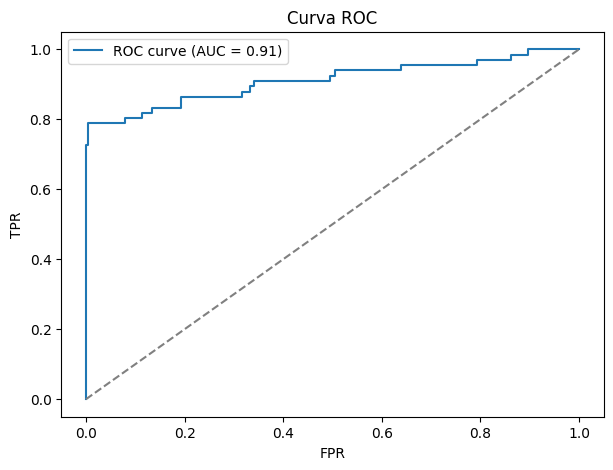

In [13]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(yc_test, yc_pred_prob)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('Curva ROC')
plt.legend()
plt.show()

In [14]:
# Encontrando o melhor limiar para F1 Score
from sklearn.metrics import f1_score
best_f1 = 0
best_thresh = 0.5
for thresh in np.arange(0.1, 0.9, 0.01):
    pred = (yc_pred_prob >= thresh).astype(int)
    score = f1_score(yc_test, pred)
    if score > best_f1:
        best_f1 = score
        best_thresh = thresh

print(f'Melhor limiar para F1: {best_thresh:.2f} (F1={best_f1:.3f})')
yc_pred_best = (yc_pred_prob >= best_thresh).astype(int)
cm_best = confusion_matrix(yc_test, yc_pred_best)
print('Matriz de Confusão (melhor F1):')
print(cm_best)

Melhor limiar para F1: 0.79 (F1=0.874)
Matriz de Confusão (melhor F1):
[[201   1]
 [ 14  52]]


## Boas Práticas e Pipeline
- O split entre treino e teste foi realizado antes do pré-processamento para evitar vazamento de dados.
- O pipeline inclui pré-processamento (padronização e one-hot) e o modelo, garantindo reprodutibilidade.
- Charges não foi usada como preditora na classificação.
- As métricas foram avaliadas no conjunto de teste, sem usar dados do treino.

## Interpretação dos coeficientes e importância das variáveis
- Na regressão, coeficientes positivos indicam aumento do custo médico conforme a variável aumenta (após escala).
- Na classificação, coeficientes positivos indicam maior chance de ser alto custo.
- Smoker e BMI costumam ser os mais relevantes.



## Extra: Validação cruzada e regularização

In [15]:
# Validação cruzada na regressão
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(reg_pipeline, X, y, cv=5, scoring='r2')
print('R² (validação cruzada):', cv_scores)
print('Média R²:', np.mean(cv_scores))

R² (validação cruzada): [0.76148179 0.70649339 0.77806343 0.73269475 0.75557475]
Média R²: 0.7468616243473741


In [16]:
# Testando regularização na classificação logística
clf_pipeline_l2 = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(C=0.1, max_iter=1000))
])
clf_pipeline_l2.fit(Xc_train, yc_train)
yc_pred_l2 = clf_pipeline_l2.predict(Xc_test)
f1_l2 = f1_score(yc_test, yc_pred_l2)
print(f'F1 Score com regularização (C=0.1): {f1_l2:.3f}')

F1 Score com regularização (C=0.1): 0.867
